In [ ]:
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import time
import io

compile_cmd = ["nvcc", "-O3", "-arch=sm_90", "generalmatrixmultiplication.cu", "-o", "gemm_runner"]
subprocess.run(compile_cmd, check=True)

sizes = [128, 256, 512, 1024, 2048, 4096, 8192, 16384]
csv_data = "n,k,m,CpuNaive,CpuOpt,GpuNaive,GpuSingle,GpuMemCoal,Gpu2dTiling,Gpu2dMult,Gpu2dBlock\n"

numpy_times = []

print("Running benchmarks...")
for size in sizes:
    print(f"Benchmarking size: {size}x{size}x{size}")
    
    result = subprocess.run(
        ["./gemm_runner", "1", str(size), str(size), str(size)], 
        capture_output=True, 
        text=True
    )
    
    csv_data += result.stdout

    if(size <= 4096):
        x1 = np.random.rand(size, size).astype(np.float32)
        x2 = np.random.rand(size, size).astype(np.float32)
        
        # Warmup runs
        for _ in range(3):
            _ = np.matmul(x1, x2)
            
        # Timed runs (scale down the iterations for massive matrices so you don't wait forever)
        run_cnt = 20
        
        times = []
        for _ in range(run_cnt):
            t_start = time.time()
            _ = np.matmul(x1, x2)
            t_end = time.time()
            times.append(t_end - t_start)
            
        numpy_times.append(np.mean(times))
    else:
        numpy_times.append(-1.0)

print("Benchmarking complete!")

Running benchmarks...
Benchmarking size: 128x128x128
Benchmarking size: 256x256x256
Benchmarking size: 512x512x512
Benchmarking size: 1024x1024x1024
Benchmarking size: 2048x2048x2048
Benchmarking size: 4096x4096x4096
Benchmarking size: 8192x8192x8192
Benchmarking size: 16384x16384x16384


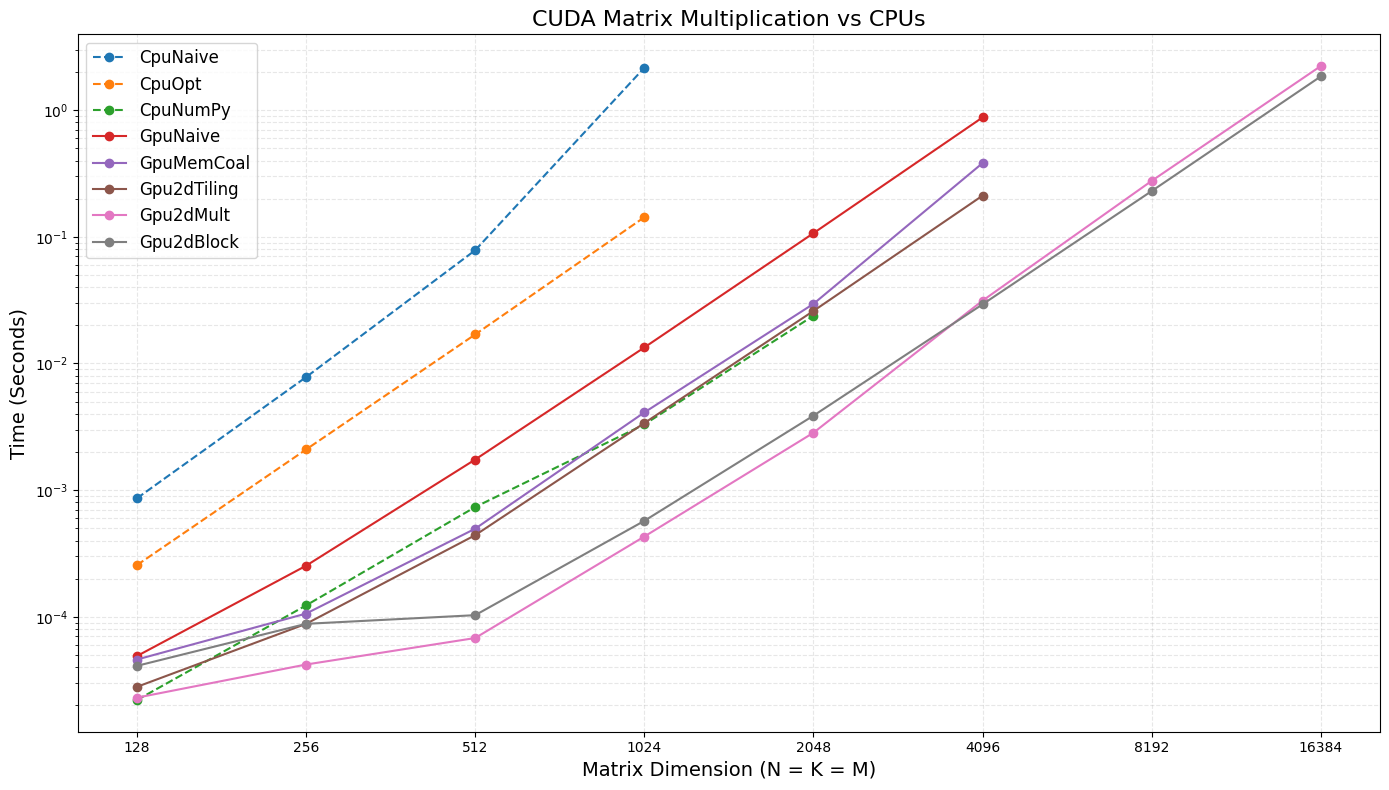

In [16]:
df = pd.read_csv(io.StringIO(csv_data))

df['CpuNumPy'] = numpy_times

#Replace C++ -1.0 with NaN so Matplotlib breaks the line
df.replace(-1.0, np.nan, inplace=True)

plt.figure(figsize=(14, 8))

# Define all columns we want to plot
plot_columns = [
    'CpuNaive', 'CpuOpt', 'CpuNumPy', 
    'GpuNaive', 'GpuMemCoal', 'Gpu2dTiling', 'Gpu2dMult', 'Gpu2dBlock'
]

# Plot each column
for col in plot_columns:
    # Filter out the NaN values for this specific line
    valid_data = df[['n', col]].dropna()
    
    # Make CPU lines dashed and GPU lines solid
    linestyle = '--' if 'Cpu' in col else '-'
    
    # Thicken the lines for the two heavyweights
    linewidth = 1.5
    
    plt.plot(
        valid_data['n'], 
        valid_data[col], 
        marker='o', 
        linestyle=linestyle, 
        linewidth=linewidth, 
        label=col
    )

plt.title('CUDA Matrix Multiplication vs CPUs', fontsize=16)
plt.xlabel('Matrix Dimension (N = K = M)', fontsize=14)
plt.ylabel('Time (Seconds)', fontsize=14)

# Keep the log scales!
plt.yscale('log') 
plt.xscale('log', base=2)
plt.xticks(sizes, labels=[str(s) for s in sizes])

plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend(fontsize=12, loc='upper left')
plt.tight_layout()

plt.show()